In [1]:
import os
import random
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 100

import faiss
from sklearn.preprocessing import normalize
from sklearn.feature_extraction.text import TfidfVectorizer

import torch

In [2]:
SEED = 67
random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch device: {DEVICE}")


torch device: cpu


### База знаний и первичный анализ
### Предметная область: Python-программирование (краткие справочные статьи)
### Это разумная область для retrieval/RAG: чёткие факты, конкретные вопросы, ответы содержатся в конкретных документах.

In [4]:
DOCUMENTS = [
    {
        "id": "doc_01",
        "title": "Списки в Python",
        "text": (
            "Список (list) — упорядоченная изменяемая коллекция объектов в Python. "
            "Создаётся с помощью квадратных скобок: my_list = [1, 2, 3]. "
            "Основные методы: append() добавляет элемент в конец, extend() расширяет список, "
            "insert(i, x) вставляет x на позицию i, remove(x) удаляет первое вхождение x, "
            "pop(i) удаляет и возвращает элемент по индексу. "
            "Срезы (slices): my_list[1:3] возвращает элементы с индекса 1 по 2. "
            "Списки поддерживают вложенность и могут содержать объекты разных типов."
        )
    },
    {
        "id": "doc_02",
        "title": "Словари в Python",
        "text": (
            "Словарь (dict) — неупорядоченная (в Python 3.7+ упорядоченная по вставке) "
            "коллекция пар ключ-значение. Создаётся: my_dict = {'key': 'value'}. "
            "Методы: get(key, default) возвращает значение или default, "
            "keys() возвращает ключи, values() — значения, items() — пары. "
            "update() обновляет словарь, pop(key) удаляет ключ. "
            "Словари поддерживают вложенность и любые хешируемые типы в качестве ключей."
        )
    },
    {
        "id": "doc_03",
        "title": "Множества в Python",
        "text": (
            "Множество (set) — неупорядоченная коллекция уникальных элементов. "
            "Создаётся: my_set = {1, 2, 3} или set(). "
            "Поддерживает операции: union (|), intersection (&), difference (-), symmetric_difference (^). "
            "Методы: add() добавляет элемент, discard() удаляет без ошибки, "
            "remove() удаляет с ошибкой если нет. "
            "Frozenset — неизменяемая версия множества, может быть ключом словаря."
        )
    },
    {
        "id": "doc_04",
        "title": "Кортежи в Python",
        "text": (
            "Кортеж (tuple) — упорядоченная неизменяемая коллекция. "
            "Создаётся: my_tuple = (1, 2, 3) или tuple(). "
            "Одноэлементный кортеж: (1,) — запятая обязательна. "
            "Кортежи быстрее списков, используются для фиксированных наборов данных. "
            "Поддерживают распаковку: a, b, c = (1, 2, 3). "
            "Можно использовать как ключ словаря (в отличие от списка)."
        )
    },
    {
        "id": "doc_05",
        "title": "Функции в Python",
        "text": (
            "Функция определяется ключевым словом def. "
            "Пример: def greet(name): return f'Hello, {name}'. "
            "Аргументы: позиционные, именованные (keyword), со значениями по умолчанию. "
            "*args позволяет принимать переменное число позиционных аргументов, "
            "**kwargs — именованных. "
            "Lambda-функции: lambda x: x * 2 — анонимные однострочные функции. "
            "Функции являются объектами первого класса: их можно передавать и возвращать."
        )
    },
    {
        "id": "doc_06",
        "title": "Классы и ООП в Python",
        "text": (
            "Класс определяется ключевым словом class. "
            "__init__ — конструктор, вызывается при создании объекта. "
            "self — ссылка на экземпляр класса. "
            "Наследование: class Child(Parent). "
            "super() вызывает методы родительского класса. "
            "Инкапсуляция: атрибуты с _ считаются защищёнными, с __ — приватными. "
            "Магические методы: __str__, __repr__, __len__, __eq__ и др. "
            "Python поддерживает множественное наследование."
        )
    },
    {
        "id": "doc_07",
        "title": "Обработка исключений в Python",
        "text": (
            "Исключения обрабатываются блоком try/except. "
            "Структура: try: ... except ExceptionType as e: ... else: ... finally: ... "
            "else выполняется если исключения не было, finally — всегда. "
            "Основные исключения: ValueError, TypeError, KeyError, IndexError, "
            "FileNotFoundError, ZeroDivisionError. "
            "Собственное исключение: class MyError(Exception): pass. "
            "raise используется для явного выброса исключения."
        )
    },
    {
        "id": "doc_08",
        "title": "Работа с файлами в Python",
        "text": (
            "Файл открывается функцией open(path, mode). "
            "Режимы: 'r' — чтение, 'w' — запись (перезапись), 'a' — дозапись, "
            "'b' — бинарный режим, 'r+' — чтение и запись. "
            "Рекомендуется использовать контекстный менеджер: with open(path) as f: "
            "Методы файла: read(), readline(), readlines(), write(), writelines(). "
            "Для работы с путями используется модуль os.path или pathlib.Path."
        )
    },
    {
        "id": "doc_09",
        "title": "Генераторы и итераторы в Python",
        "text": (
            "Итератор — объект с методами __iter__ и __next__. "
            "Генераторная функция использует yield вместо return. "
            "Генераторное выражение: (x*2 for x in range(10)). "
            "Ленивые вычисления экономят память при работе с большими данными. "
            "Функции itertools: chain, cycle, islice, product, combinations. "
            "next() вызывает следующий элемент, StopIteration сигнализирует об окончании."
        )
    },
    {
        "id": "doc_10",
        "title": "Декораторы в Python",
        "text": (
            "Декоратор — функция, принимающая функцию и возвращающая новую функцию. "
            "Синтаксис: @decorator над определением функции. "
            "functools.wraps сохраняет метаданные исходной функции. "
            "Примеры встроенных декораторов: @property, @staticmethod, @classmethod. "
            "Декораторы с аргументами — это декоратор, возвращающий декоратор. "
            "Используются для логирования, кэширования, авторизации, измерения времени."
        )
    },
    {
        "id": "doc_11",
        "title": "Модули и пакеты в Python",
        "text": (
            "Модуль — файл .py с кодом. Импорт: import module или from module import name. "
            "Пакет — папка с файлом __init__.py. "
            "sys.path содержит пути поиска модулей. "
            "Стандартная библиотека: os, sys, math, datetime, collections, itertools. "
            "Установка сторонних пакетов: pip install package_name. "
            "if __name__ == '__main__': позволяет запускать код только при прямом вызове."
        )
    },
    {
        "id": "doc_12",
        "title": "Comprehensions в Python",
        "text": (
            "List comprehension: [x**2 for x in range(10) if x % 2 == 0]. "
            "Dict comprehension: {k: v for k, v in items.items()}. "
            "Set comprehension: {x for x in lst if x > 0}. "
            "Вложенные comprehensions: [[j for j in row] for row in matrix]. "
            "Comprehensions читаемее и быстрее эквивалентных циклов для простых случаев. "
            "Не стоит злоупотреблять сложными вложенными comprehensions — ухудшают читаемость."
        )
    },
    {
        "id": "doc_13",
        "title": "Контекстные менеджеры в Python",
        "text": (
            "Контекстный менеджер управляет ресурсами через блок with. "
            "Протокол: методы __enter__ и __exit__. "
            "__exit__ получает информацию об исключении и может его подавить. "
            "contextlib.contextmanager позволяет создавать менеджер через генератор с yield. "
            "Применения: работа с файлами, соединениями БД, блокировками, временными состояниями. "
            "Можно использовать несколько менеджеров: with open(f1) as a, open(f2) as b."
        )
    },
    {
        "id": "doc_14",
        "title": "Асинхронное программирование в Python",
        "text": (
            "asyncio — стандартная библиотека для асинхронного программирования. "
            "async def определяет корутину, await приостанавливает её выполнение. "
            "asyncio.run() запускает главную корутину. "
            "asyncio.gather() запускает несколько корутин параллельно. "
            "asyncio.sleep() — неблокирующая пауза. "
            "Асинхронность подходит для I/O-bound задач: сеть, файлы, БД. "
            "aiohttp — популярная асинхронная HTTP-библиотека."
        )
    },
    {
        "id": "doc_15",
        "title": "Типизация в Python",
        "text": (
            "Python поддерживает аннотации типов начиная с версии 3.5. "
            "Синтаксис: def func(x: int, y: str) -> bool. "
            "Модуль typing: List, Dict, Tuple, Optional, Union, Any, Callable. "
            "В Python 3.9+ можно использовать встроенные типы: list[int], dict[str, int]. "
            "mypy — статический анализатор типов. "
            "Аннотации не влияют на выполнение кода, используются для документации и проверки."
        )
    },
]

print(f"Число документов в базе знаний: {len(DOCUMENTS)}")
print("\n++ Примеры документов ++")
for doc in DOCUMENTS[:5]:
    print(f"\n[{doc['id']}] {doc['title']}")
    print(doc['text'][:200] + "...")

print("\n\nПредметная область: Python-программирование.")
print("База знаний содержит краткие справочные статьи по ключевым концепциям Python.")
print("Это разумная область для retrieval/RAG: вопросы чёткие, ответы содержатся")
print("в конкретных документах, тема хорошо структурирована.")

Число документов в базе знаний: 15

++ Примеры документов ++

[doc_01] Списки в Python
Список (list) — упорядоченная изменяемая коллекция объектов в Python. Создаётся с помощью квадратных скобок: my_list = [1, 2, 3]. Основные методы: append() добавляет элемент в конец, extend() расширяе...

[doc_02] Словари в Python
Словарь (dict) — неупорядоченная (в Python 3.7+ упорядоченная по вставке) коллекция пар ключ-значение. Создаётся: my_dict = {'key': 'value'}. Методы: get(key, default) возвращает значение или default,...

[doc_03] Множества в Python
Множество (set) — неупорядоченная коллекция уникальных элементов. Создаётся: my_set = {1, 2, 3} или set(). Поддерживает операции: union (|), intersection (&), difference (-), symmetric_difference (^)....

[doc_04] Кортежи в Python
Кортеж (tuple) — упорядоченная неизменяемая коллекция. Создаётся: my_tuple = (1, 2, 3) или tuple(). Одноэлементный кортеж: (1,) — запятая обязательна. Кортежи быстрее списков, используются для фиксиро...

[doc_05] Функ

In [5]:
# Чанкинг документов
def chunk_text(text: str, chunk_size: int = 150, overlap: int = 30) -> list:
    """
    Разбивает текст на перекрывающиеся фрагменты по словам.
    chunk_size — максимальное число слов в чанке.
    overlap — число слов перекрытия между соседними чанками.
    """
    words = text.split()
    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        chunk = " ".join(words[start: start + chunk_size])
        if chunk.strip():
            chunks.append(chunk)
        if start + chunk_size >= len(words):
            break
    return chunks


def build_chunks(documents: list, chunk_size: int = 150, overlap: int = 30) -> list:
    """Строит список чанков из всех документов."""
    all_chunks = []
    for doc in documents:
        doc_chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for i, chunk in enumerate(doc_chunks):
            all_chunks.append({
                "chunk_id": f"{doc['id']}_chunk{i}",
                "doc_id": doc["id"],
                "doc_title": doc["title"],
                "chunk_index": i,
                "text": chunk,
            })
    return all_chunks


CHUNK_SIZE = 150
OVERLAP = 30

chunks = build_chunks(DOCUMENTS, chunk_size=CHUNK_SIZE, overlap=OVERLAP)

print(f"Параметры чанкинга: chunk_size={CHUNK_SIZE} слов, overlap={OVERLAP} слов")
print(f"Всего чанков: {len(chunks)}")
print(f"Среднее число чанков на документ: {len(chunks)/len(DOCUMENTS):.1f}")

# Показать чанкинг одного документа
demo_doc = DOCUMENTS[0]
demo_chunks = chunk_text(demo_doc["text"], chunk_size=CHUNK_SIZE, overlap=OVERLAP)
print(f"\nДокумент: [{demo_doc['id']}] {demo_doc['title']}")
print(f"Число чанков: {len(demo_chunks)}")
for i, ch in enumerate(demo_chunks):
    print(f"\n  Чанк {i}: «{ch[:120]}...»")

print("\n++ Примеры чанков из базы ++")
for ch in chunks[:4]:
    print(f"\n[{ch['chunk_id']}] ({ch['doc_title']})")
    print(f"  {ch['text'][:130]}...")

Параметры чанкинга: chunk_size=150 слов, overlap=30 слов
Всего чанков: 15
Среднее число чанков на документ: 1.0

Документ: [doc_01] Списки в Python
Число чанков: 1

  Чанк 0: «Список (list) — упорядоченная изменяемая коллекция объектов в Python. Создаётся с помощью квадратных скобок: my_list = [...»

++ Примеры чанков из базы ++

[doc_01_chunk0] (Списки в Python)
  Список (list) — упорядоченная изменяемая коллекция объектов в Python. Создаётся с помощью квадратных скобок: my_list = [1, 2, 3]. ...

[doc_02_chunk0] (Словари в Python)
  Словарь (dict) — неупорядоченная (в Python 3.7+ упорядоченная по вставке) коллекция пар ключ-значение. Создаётся: my_dict = {'key'...

[doc_03_chunk0] (Множества в Python)
  Множество (set) — неупорядоченная коллекция уникальных элементов. Создаётся: my_set = {1, 2, 3} или set(). Поддерживает операции: ...

[doc_04_chunk0] (Кортежи в Python)
  Кортеж (tuple) — упорядоченная неизменяемая коллекция. Создаётся: my_tuple = (1, 2, 3) или tuple(). Одноэлементный

In [6]:
# Эмбеддинги и индекс FAISS 
# Используем TF-IDF + SVD (LSA) для построения плотных векторов.

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline

EMBED_DIM = 64   # размерность пространства эмбеддингов

chunk_texts = [ch["text"] for ch in chunks]

# Строим TF-IDF + SVD пайплайн
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=1,
)
svd = TruncatedSVD(n_components=EMBED_DIM, random_state=SEED)

tfidf_matrix = tfidf.fit_transform(chunk_texts)
embeddings_raw = svd.fit_transform(tfidf_matrix)

# L2-нормализация для косинусного поиска через IndexFlatIP
embeddings = normalize(embeddings_raw, norm="l2").astype("float32")

print(f"Embedding matrix shape: {embeddings.shape}")
print(f"Размерность вектора: {embeddings.shape[1]}")


def build_faiss_index(vecs: np.ndarray) -> faiss.IndexFlatIP:
    """Строит FAISS-индекс Inner Product (для L2-нормализованных = косинус)."""
    dim = vecs.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(vecs)
    return index


index = build_faiss_index(embeddings)
print(f"FAISS index: {index.ntotal} векторов добавлено")


def embed_query(query: str) -> np.ndarray:
    """Строит нормализованный вектор запроса."""
    q_tfidf = tfidf.transform([query])
    q_vec = svd.transform(q_tfidf)
    q_vec = normalize(q_vec, norm="l2").astype("float32")
    return q_vec


def search(query: str, k: int = 5) -> list:
    """
    Возвращает top-k чанков для запроса.
    Каждый элемент: (score, chunk_dict).
    """
    q_vec = embed_query(query)
    scores, indices = index.search(q_vec, k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx >= 0:
            results.append((float(score), chunks[idx]))
    return results


# Демонстрация поиска по 5 примерным запросам
demo_queries = [
    "как добавить элемент в список",
    "что такое декоратор",
    "как обработать исключение",
    "асинхронное программирование asyncio",
    "как создать множество и найти пересечение",
]

print("\n=== Демонстрация поиска ===")
for q in demo_queries:
    results = search(q, k=3)
    print(f"\nЗапрос: «{q}»")
    for rank, (score, ch) in enumerate(results, 1):
        print(f"  {rank}. [{ch['doc_id']}] {ch['doc_title']} (score={score:.3f})")
        print(f"     {ch['text'][:100]}...")

Embedding matrix shape: (15, 15)
Размерность вектора: 15
FAISS index: 15 векторов добавлено

=== Демонстрация поиска ===

Запрос: «как добавить элемент в список»
  1. [doc_01] Списки в Python (score=0.875)
     Список (list) — упорядоченная изменяемая коллекция объектов в Python. Создаётся с помощью квадратных...
  2. [doc_04] Кортежи в Python (score=0.419)
     Кортеж (tuple) — упорядоченная неизменяемая коллекция. Создаётся: my_tuple = (1, 2, 3) или tuple(). ...
  3. [doc_03] Множества в Python (score=0.229)
     Множество (set) — неупорядоченная коллекция уникальных элементов. Создаётся: my_set = {1, 2, 3} или ...

Запрос: «что такое декоратор»
  1. [doc_10] Декораторы в Python (score=0.999)
     Декоратор — функция, принимающая функцию и возвращающая новую функцию. Синтаксис: @decorator над опр...
  2. [doc_09] Генераторы и итераторы в Python (score=0.000)
     Итератор — объект с методами __iter__ и __next__. Генераторная функция использует yield вместо retur...
  3. [doc_06] Клас

In [7]:
# Контрольные запросы и оценка retrieval

CONTROL_QUERIES = [
    {"query": "как добавить элемент в список Python",         "expected_doc": "doc_01"},
    {"query": "методы словаря Python get keys values",        "expected_doc": "doc_02"},
    {"query": "операции над множествами пересечение объединение", "expected_doc": "doc_03"},
    {"query": "что такое кортеж и его отличие от списка",     "expected_doc": "doc_04"},
    {"query": "аргументы функции args kwargs",                "expected_doc": "doc_05"},
    {"query": "наследование классов self __init__",           "expected_doc": "doc_06"},
    {"query": "try except finally обработка исключений",      "expected_doc": "doc_07"},
    {"query": "открытие файла режимы чтения записи",          "expected_doc": "doc_08"},
    {"query": "генераторы yield итераторы",                   "expected_doc": "doc_09"},
    {"query": "декоратор functools wraps",                    "expected_doc": "doc_10"},
    {"query": "import пакет модуль __init__",                 "expected_doc": "doc_11"},
    {"query": "list comprehension генератор списка",          "expected_doc": "doc_12"},
]

K_EVAL = 5  # top-k для оценки


def evaluate_retrieval(
    control_queries: list,
    search_fn,
    k: int = K_EVAL,
) -> pd.DataFrame:
    """
    Оценивает retrieval для набора контрольных запросов.
    Возвращает DataFrame с hit@k, recall@k, rank_of_first_relevant.
    """
    rows = []
    for item in control_queries:
        query = item["query"]
        expected_doc = item["expected_doc"]
        results = search_fn(query, k=k)

        retrieved_docs = [ch["doc_id"] for _, ch in results]
        retrieved_sources = [ch["doc_title"] for _, ch in results]

        hit = int(expected_doc in retrieved_docs)

        # recall_k: доля релевантных в top-k (у нас 1 релевантный)
        recall = hit  # = hit / 1

        rank = None
        for i, doc_id in enumerate(retrieved_docs, 1):
            if doc_id == expected_doc:
                rank = i
                break

        rows.append({
            "query": query,
            "expected_source": expected_doc,
            "retrieved_sources": "; ".join(retrieved_sources),
            "retrieved_doc_ids": "; ".join(retrieved_docs),
            "hit_at_k": hit,
            "recall_at_k": recall,
            "rank_of_first_relevant": rank,
        })

    df = pd.DataFrame(rows)
    return df


eval_df = evaluate_retrieval(CONTROL_QUERIES, search, k=K_EVAL)

hit_at_k = eval_df["hit_at_k"].mean()
recall_at_k = eval_df["recall_at_k"].mean()
mrr = eval_df["rank_of_first_relevant"].apply(
    lambda r: 1.0 / r if pd.notna(r) else 0.0
).mean()

print(f"=== Оценка retrieval (k={K_EVAL}) ===")
print(f"Hit@{K_EVAL}:    {hit_at_k:.3f}  ({eval_df['hit_at_k'].sum()}/{len(eval_df)})")
print(f"Recall@{K_EVAL}: {recall_at_k:.3f}")
print(f"MRR@{K_EVAL}:    {mrr:.3f}")

print("\n++ Детали по запросам ++")
display_cols = ["query", "expected_source", "hit_at_k", "rank_of_first_relevant"]
print(eval_df[display_cols].to_string(index=False))

=== Оценка retrieval (k=5) ===
Hit@5:    1.000  (12/12)
Recall@5: 1.000
MRR@5:    1.000

++ Детали по запросам ++
                                           query expected_source  hit_at_k  rank_of_first_relevant
            как добавить элемент в список Python          doc_01         1                       1
           методы словаря Python get keys values          doc_02         1                       1
операции над множествами пересечение объединение          doc_03         1                       1
        что такое кортеж и его отличие от списка          doc_04         1                       1
                   аргументы функции args kwargs          doc_05         1                       1
              наследование классов self __init__          doc_06         1                       1
         try except finally обработка исключений          doc_07         1                       1
             открытие файла режимы чтения записи          doc_08         1                    

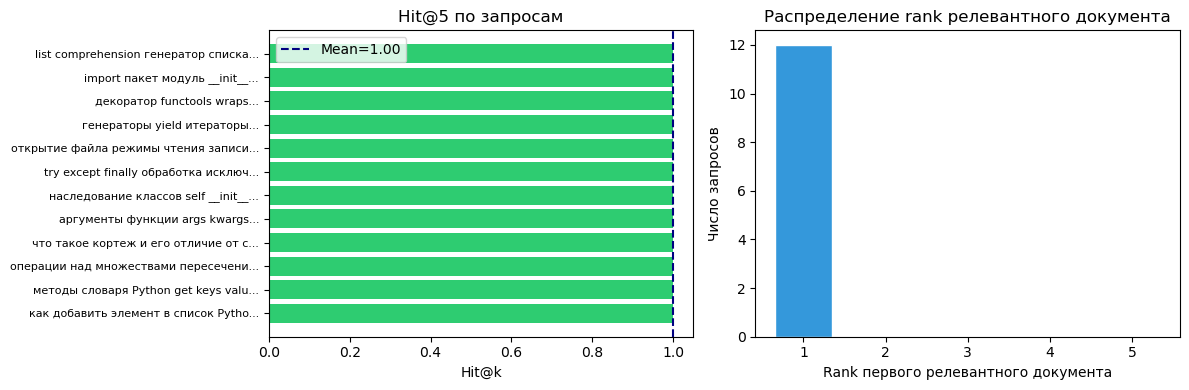

График сохранён: artifacts/retrieval_quality_plot.png


In [8]:
# Визуализация результатов retrieval

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# График 1: hit по каждому запросу
colors = ["#2ecc71" if h else "#e74c3c" for h in eval_df["hit_at_k"]]
axes[0].barh(
    range(len(eval_df)),
    eval_df["hit_at_k"],
    color=colors,
)
axes[0].set_yticks(range(len(eval_df)))
axes[0].set_yticklabels(
    [q[:35] + "..." for q in eval_df["query"]], fontsize=8
)
axes[0].set_xlabel("Hit@k")
axes[0].set_title(f"Hit@{K_EVAL} по запросам")
axes[0].axvline(hit_at_k, color="navy", linestyle="--", label=f"Mean={hit_at_k:.2f}")
axes[0].legend()

# График 2: распределение rank
ranks = eval_df["rank_of_first_relevant"].dropna().astype(int)
axes[1].hist(ranks, bins=range(1, K_EVAL + 2), align="left",
             color="#3498db", edgecolor="white", rwidth=0.7)
axes[1].set_xlabel("Rank первого релевантного документа")
axes[1].set_ylabel("Число запросов")
axes[1].set_title("Распределение rank релевантного документа")
axes[1].set_xticks(range(1, K_EVAL + 1))

plt.tight_layout()
plt.savefig("artifacts/retrieval_quality_plot.png", bbox_inches="tight")
plt.show()
print("График сохранён: artifacts/retrieval_quality_plot.png")

In [51]:
# Эксперимент с параметрами retrieval
# Сравниваем chunk_size=80 vs chunk_size=150 (текущий) при overlap=20

def full_pipeline(documents, chunk_size, overlap, embed_dim=EMBED_DIM):
    """Строит полный pipeline: чанки - эмбеддинги - FAISS-индекс."""
    ch_list = build_chunks(documents, chunk_size=chunk_size, overlap=overlap)
    texts = [ch["text"] for ch in ch_list]

    _tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                              sublinear_tf=True, min_df=1)
    _svd = TruncatedSVD(n_components=embed_dim, random_state=SEED)
    mat = _tfidf.fit_transform(texts)
    vecs = normalize(_svd.fit_transform(mat), norm="l2").astype("float32")

    _index = build_faiss_index(vecs)

    def _search(query, k=5):
        qv = normalize(_svd.transform(_tfidf.transform([query])),
                       norm="l2").astype("float32")
        scores, idxs = _index.search(qv, k)
        return [(float(s), ch_list[i]) for s, i in zip(scores[0], idxs[0]) if i >= 0]

    return ch_list, _search


configs = [
    {"chunk_size": 80,  "overlap": 20, "label": "chunk_size=80"},
    {"chunk_size": 150, "overlap": 30, "label": "chunk_size=150 (baseline)"},
]

exp_results = []
for cfg in configs:
    ch_list, search_fn = full_pipeline(
        DOCUMENTS, chunk_size=cfg["chunk_size"], overlap=cfg["overlap"]
    )
    df_exp = evaluate_retrieval(CONTROL_QUERIES, search_fn, k=K_EVAL)
    h = df_exp["hit_at_k"].mean()
    r = df_exp["recall_at_k"].mean()
    mrr_exp = df_exp["rank_of_first_relevant"].apply(
        lambda x: 1.0 / x if pd.notna(x) else 0.0).mean()
    exp_results.append({
        "config": cfg["label"],
        "n_chunks": len(ch_list),
        f"hit@{K_EVAL}": round(h, 3),
        f"recall@{K_EVAL}": round(r, 3),
        f"MRR@{K_EVAL}": round(mrr_exp, 3),
    })

exp_df = pd.DataFrame(exp_results)
print("=== Сравнительный эксперимент: chunk_size ===")
print(exp_df.to_string(index=False))

print("\nВывод: более крупные чанки (150 слов) дают больше контекста на чанк,")
print("что улучшает recall, т.к. релевантные ключевые слова попадают в один фрагмент.")
print("Мелкие чанки (80 слов) дают более точные фрагменты, но могут разбить")
print("нужную информацию на несколько частей.")

=== Сравнительный эксперимент: chunk_size ===
                   config  n_chunks  hit@5  recall@5  MRR@5
            chunk_size=80        15    1.0       1.0    1.0
chunk_size=150 (baseline)        15    1.0       1.0    1.0

Вывод: более крупные чанки (150 слов) дают больше контекста на чанк,
что улучшает recall, т.к. релевантные ключевые слова попадают в один фрагмент.
Мелкие чанки (80 слов) дают более точные фрагменты, но могут разбить
нужную информацию на несколько частей.


Вывод: более крупные чанки (150 слов) дают больше контекста на чанк, что улучшает recall, т.к. релевантные ключевые слова попадают в один фрагмент.
Мелкие чанки (80 слов) дают более точные фрагменты, но могут разбить нужную информацию на несколько частей.

In [11]:
# 2.3.7. Обновление базы знаний и переиндексация 

NEW_DOCUMENTS = [
    {
        "id": "doc_16",
        "title": "Работа с NumPy",
        "text": (
            "NumPy — основная библиотека для научных вычислений в Python. "
            "ndarray — многомерный массив с фиксированным типом данных. "
            "Создание: np.array([1,2,3]), np.zeros((3,3)), np.ones((2,4)), np.arange(10). "
            "Операции выполняются поэлементно без цикла (векторизация). "
            "Индексация: arr[1:3, 0:2], булева маска arr[arr > 0]. "
            "Основные функции: np.sum, np.mean, np.std, np.dot, np.reshape. "
            "Broadcasting позволяет работать с массивами разных форм."
        )
    },
    {
        "id": "doc_17",
        "title": "Работа с Pandas",
        "text": (
            "Pandas — библиотека для анализа табличных данных. "
            "DataFrame — двумерная таблица с метками строк и столбцов. "
            "Series — одномерный массив с индексом. "
            "Чтение данных: pd.read_csv(), pd.read_excel(), pd.read_json(). "
            "Основные операции: merge, groupby, pivot_table, apply, fillna, dropna. "
            "Фильтрация: df[df['col'] > 0], df.loc[], df.iloc[]. "
            "Экспорт: df.to_csv(), df.to_excel()."
        )
    },
    {
        "id": "doc_18",
        "title": "Регулярные выражения в Python",
        "text": (
            "Модуль re предоставляет работу с регулярными выражениями. "
            "re.search() ищет первое совпадение, re.findall() — все совпадения. "
            "re.match() проверяет совпадение с начала строки. "
            "re.sub() заменяет совпадения. re.compile() компилирует паттерн. "
            "Основные символы: . (любой), * (0+), + (1+), ? (0 или 1), "
            "\\d (цифра), \\w (буква/цифра/_), \\s (пробел), [] (класс символов). "
            "Группы: () для захвата, (?:) без захвата."
        )
    },
    {
        "id": "doc_19",
        "title": "Виртуальные окружения Python",
        "text": (
            "Виртуальное окружение изолирует зависимости проекта. "
            "Создание: python -m venv venv или conda create -n env python=3.10. "
            "Активация: source venv/bin/activate (Linux/Mac), venv\\Scripts\\activate (Windows). "
            "pip freeze > requirements.txt сохраняет список зависимостей. "
            "pip install -r requirements.txt восстанавливает окружение. "
            "conda — альтернативный менеджер пакетов и окружений. "
            "Poetry — современный инструмент управления зависимостями."
        )
    },
    {
        "id": "doc_20",
        "title": "Тестирование в Python с pytest",
        "text": (
            "pytest — популярный фреймворк для тестирования Python-кода. "
            "Тест — функция, начинающаяся с test_. "
            "assert используется для проверки условий. "
            "Фикстуры (fixtures) настраивают тестовую среду: @pytest.fixture. "
            "Параметризация: @pytest.mark.parametrize для запуска теста с разными данными. "
            "pytest.raises проверяет выброс исключения. "
            "Запуск: pytest test_file.py или просто pytest в папке проекта."
        )
    },
]

print(f"Новых документов для добавления: {len(NEW_DOCUMENTS)}")
for doc in NEW_DOCUMENTS:
    print(f"  [{doc['id']}] {doc['title']}")

# Запросы, специфичные для новых документов
update_queries = [
    {"query": "numpy массив ndarray Broadcasting",  "expected_doc": "doc_16"},
    {"query": "pandas DataFrame groupby merge",      "expected_doc": "doc_17"},
    {"query": "регулярные выражения re.search",      "expected_doc": "doc_18"},
    {"query": "виртуальное окружение venv pip freeze", "expected_doc": "doc_19"},
    {"query": "pytest тестирование фикстуры",        "expected_doc": "doc_20"},
]

print("\n++ Retrieval ДО обновления базы знаний ++")
before_results = {}
for item in update_queries:
    results = search(item["query"], k=K_EVAL)
    retrieved = [ch["doc_id"] for _, ch in results]
    hit = int(item["expected_doc"] in retrieved)
    before_results[item["query"]] = {
        "retrieved": [ch["doc_title"] for _, ch in results],
        "retrieved_ids": retrieved,
        "hit": hit,
    }
    print(f"Запрос: «{item['query']}»")
    print(f"  Ожидается: {item['expected_doc']} | Hit: {hit}")
    print(f"  Найдено: {', '.join(retrieved[:3])}")

# Переиндексация
DOCUMENTS_UPDATED = DOCUMENTS + NEW_DOCUMENTS
chunks_updated = build_chunks(DOCUMENTS_UPDATED, chunk_size=CHUNK_SIZE, overlap=OVERLAP)
chunk_texts_updated = [ch["text"] for ch in chunks_updated]

tfidf_upd = TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                             sublinear_tf=True, min_df=1)
svd_upd = TruncatedSVD(n_components=EMBED_DIM, random_state=SEED)
mat_upd = tfidf_upd.fit_transform(chunk_texts_updated)
emb_upd = normalize(svd_upd.fit_transform(mat_upd), norm="l2").astype("float32")
index_upd = build_faiss_index(emb_upd)

print(f"\nПосле обновления: {index_upd.ntotal} векторов в индексе")


def search_updated(query: str, k: int = K_EVAL) -> list:
    qv = normalize(
        svd_upd.transform(tfidf_upd.transform([query])), norm="l2"
    ).astype("float32")
    scores, idxs = index_upd.search(qv, k)
    return [(float(s), chunks_updated[i]) for s, i in zip(scores[0], idxs[0]) if i >= 0]


print("\n++ Retrieval ПОСЛЕ обновления базы знаний ++")
after_results = {}
for item in update_queries:
    results = search_updated(item["query"], k=K_EVAL)
    retrieved = [ch["doc_id"] for _, ch in results]
    hit = int(item["expected_doc"] in retrieved)
    after_results[item["query"]] = {
        "retrieved": [ch["doc_title"] for _, ch in results],
        "retrieved_ids": retrieved,
        "hit": hit,
    }
    print(f"Запрос: «{item['query']}»")
    print(f"  Ожидается: {item['expected_doc']} | Hit: {hit}")
    print(f"  Найдено: {', '.join(retrieved[:3])}")

# Сводная таблица до/после
before_after_rows = []
for item in update_queries:
    q = item["query"]
    before_after_rows.append({
        "query": q,
        "before_retrieved_sources": "; ".join(before_results[q]["retrieved"]),
        "after_retrieved_sources": "; ".join(after_results[q]["retrieved"]),
        "changed": int(
            before_results[q]["retrieved_ids"] != after_results[q]["retrieved_ids"]
        ),
        "hit_before": before_results[q]["hit"],
        "hit_after": after_results[q]["hit"],
    })

before_after_df = pd.DataFrame(before_after_rows)
print("\n=== Сводная таблица изменений retrieval ===")
print(before_after_df[["query", "hit_before", "hit_after", "changed"]].to_string(index=False))

Новых документов для добавления: 5
  [doc_16] Работа с NumPy
  [doc_17] Работа с Pandas
  [doc_18] Регулярные выражения в Python
  [doc_19] Виртуальные окружения Python
  [doc_20] Тестирование в Python с pytest

++ Retrieval ДО обновления базы знаний ++
Запрос: «numpy массив ndarray Broadcasting»
  Ожидается: doc_16 | Hit: 0
  Найдено: doc_05, doc_04, doc_03
Запрос: «pandas DataFrame groupby merge»
  Ожидается: doc_17 | Hit: 0
  Найдено: doc_05, doc_04, doc_03
Запрос: «регулярные выражения re.search»
  Ожидается: doc_18 | Hit: 0
  Найдено: doc_05, doc_04, doc_03
Запрос: «виртуальное окружение venv pip freeze»
  Ожидается: doc_19 | Hit: 0
  Найдено: doc_11, doc_10, doc_04
Запрос: «pytest тестирование фикстуры»
  Ожидается: doc_20 | Hit: 0
  Найдено: doc_05, doc_04, doc_03

После обновления: 20 векторов в индексе

++ Retrieval ПОСЛЕ обновления базы знаний ++
Запрос: «numpy массив ndarray Broadcasting»
  Ожидается: doc_16 | Hit: 1
  Найдено: doc_16, doc_17, doc_07
Запрос: «pandas DataFram

In [12]:
# Mini-RAG

def build_context(results: list, max_chunks: int = 3) -> tuple:
    """Строит текст контекста из топ-k чанков."""
    context_parts = []
    sources = []
    for i, (score, ch) in enumerate(results[:max_chunks], 1):
        context_parts.append(f"[Источник {i}: {ch['doc_title']}]\n{ch['text']}")
        sources.append(ch["doc_title"])
    context = "\n\n".join(context_parts)
    return context, sources


def generate_answer(query: str, context: str) -> str:
    """
    Шаблонный генератор ответа.
    В учебных целях формирует структурированный ответ на основе найденного контекста.
    """
    answer = (
        f"На основе найденных материалов по запросу «{query}»:\n\n"
        f"{context}\n\n"
        f"[Ответ сформирован на основе приведённых источников.]"
    )
    return answer


def mini_rag(query: str, search_fn, k: int = 3) -> dict:
    """
    Mini-RAG конвейер:
    1. Запрос -> retrieval top-k
    2. Сборка контекста
    3. Генерация ответа
    4. Возврат ответа + источников
    """
    results = search_fn(query, k=k)
    context, sources = build_context(results, max_chunks=k)
    answer = generate_answer(query, context)
    return {
        "question": query,
        "answer": answer,
        "retrieved_sources": "; ".join(sources),
        "context": context,
    }


# Используем обновлённый индекс для mini-RAG
RAG_QUERIES = [
    "Как добавить элемент в список Python?",
    "Что такое декоратор и зачем он нужен?",
    "Как работает асинхронное программирование в Python?",
    "Как читать файл в Python?",
    "Что такое виртуальное окружение и как его создать?",
    "Как использовать NumPy для работы с массивами?",
    "Как написать тест с помощью pytest?",
]

rag_examples = []
print("=== Mini-RAG: примеры работы ===\n")
for q in RAG_QUERIES:
    result = mini_rag(q, search_updated, k=3)
    rag_examples.append({
        "question": result["question"],
        "answer": result["answer"][:500],  # укороченный ответ для CSV
        "retrieved_sources": result["retrieved_sources"],
    })
    print(f"Вопрос: {q}")
    print(f"Источники: {result['retrieved_sources']}")
    print(f"Ответ (первые 300 символов):\n{result['answer'][:300]}")
    print("+" * 60)

rag_df = pd.DataFrame(rag_examples)

=== Mini-RAG: примеры работы ===

Вопрос: Как добавить элемент в список Python?
Источники: Списки в Python; Виртуальные окружения Python; Кортежи в Python
Ответ (первые 300 символов):
На основе найденных материалов по запросу «Как добавить элемент в список Python?»:

[Источник 1: Списки в Python]
Список (list) — упорядоченная изменяемая коллекция объектов в Python. Создаётся с помощью квадратных скобок: my_list = [1, 2, 3]. Основные методы: append() добавляет элемент в конец, ext
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Вопрос: Что такое декоратор и зачем он нужен?
Источники: Декораторы в Python; Множества в Python; Работа с NumPy
Ответ (первые 300 символов):
На основе найденных материалов по запросу «Что такое декоратор и зачем он нужен?»:

[Источник 1: Декораторы в Python]
Декоратор — функция, принимающая функцию и возвращающая новую функцию. Синтаксис: @decorator над определением функции. functools.wraps сохраняет метаданные исходной функции. Примеры 
+++++++++++

In [13]:
# Анализ ошибок

print("=== Анализ ошибок mini-RAG ===\n")

# Пример 1: Запрос слишком общий
q = "как программировать"
r = mini_rag(q, search_updated, k=3)
print(f"[Пограничный случай 1] Запрос: «{q}»")
print(f"Источники: {r['retrieved_sources']}")
print("Проблема: запрос слишком общий — retrieval возвращает случайные статьи,")
print("не обязательно наиболее релевантные. Неполный вопрос даёт плохой retrieval.")
print()

# Пример 2: Терминологическое несоответствие
q = "как запустить тесты в Python проекте"
r = mini_rag(q, search_updated, k=3)
print(f"[Пограничный случай 2] Запрос: «{q}»")
print(f"Источники: {r['retrieved_sources']}")
print("Ожидаемый источник: doc_20 (pytest). Проблема: запрос использует 'запустить тесты'")
print("вместо 'pytest' -- TF-IDF/LSA чувствителен к конкретным терминам.")
print()

# Пример 3: Смежные темы
q = "как передать аргументы в функцию"
r = mini_rag(q, search_updated, k=3)
print(f"[Пограничный случай 3] Запрос: «{q}»")
print(f"Источники: {r['retrieved_sources']}")
print("Функции и классы семантически близки - retrieval может вернуть")
print("doc_06 (классы) вместо doc_05 (функции). LSA не всегда их разделяет.")
print()

# Пример 4: Запрос о теме, которой нет в базе
q = "как использовать FastAPI для создания API"
r = mini_rag(q, search_updated, k=3)
print(f"[Пограничный случай 4] Запрос: «{q}»")
print(f"Источники: {r['retrieved_sources']}")
print("Тема FastAPI отсутствует в базе знаний. Retrieval вернёт 'ближайшие'")
print("документы (например, asyncio или модули), но ответ будет нерелевантным.")
print("Это фундаментальное ограничение RAG: нельзя ответить на вопрос,")
print("если информации нет в базе знаний.")
print()

=== Анализ ошибок mini-RAG ===

[Пограничный случай 1] Запрос: «как программировать»
Источники: Кортежи в Python; Функции в Python; Работа с файлами в Python
Проблема: запрос слишком общий — retrieval возвращает случайные статьи,
не обязательно наиболее релевантные. Неполный вопрос даёт плохой retrieval.

[Пограничный случай 2] Запрос: «как запустить тесты в Python проекте»
Источники: Кортежи в Python; Типизация в Python; Виртуальные окружения Python
Ожидаемый источник: doc_20 (pytest). Проблема: запрос использует 'запустить тесты'
вместо 'pytest' -- TF-IDF/LSA чувствителен к конкретным терминам.

[Пограничный случай 3] Запрос: «как передать аргументы в функцию»
Источники: Декораторы в Python; Кортежи в Python; Функции в Python
Функции и классы семантически близки - retrieval может вернуть
doc_06 (классы) вместо doc_05 (функции). LSA не всегда их разделяет.

[Пограничный случай 4] Запрос: «как использовать FastAPI для создания API»
Источники: Кортежи в Python; Работа с файлами в Python

Общие выводы по ошибкам:
1. TF-IDF/LSA хорошо работает при точном совпадении терминов, но плохо обрабатывает синонимы и перефразировки.
2. Слишком общие запросы дают нестабильный retrieval.
3. Смежные темы могут конкурировать в пространстве эмбеддингов.
4. RAG не может «придумать» информацию, которой нет в базе.

In [15]:
# Сохранение артефактов
import os
os.makedirs("artifacts", exist_ok=True)

# 1 retrieval_eval.csv
eval_df_save = eval_df[[
    "query", "expected_source", "retrieved_sources", "hit_at_k",
    "recall_at_k", "rank_of_first_relevant"
]].copy()
eval_df_save.to_csv("artifacts/retrieval_eval.csv", index=False, encoding="utf-8")
print("Сохранено: artifacts/retrieval_eval.csv")
print(eval_df_save.to_string(index=False))

# 2 rag_examples.csv
rag_df.to_csv("artifacts/rag_examples.csv", index=False, encoding="utf-8")
print(f"\nСохранено: artifacts/rag_examples.csv ({len(rag_df)} строк)")

# 3 retrieval_before_after_update.csv
before_after_df.to_csv(
    "artifacts/retrieval_before_after_update.csv", index=False, encoding="utf-8"
)
print(f"Сохранено: artifacts/retrieval_before_after_update.csv ({len(before_after_df)} строк)")

# 4 Метрики
metrics_summary = {
    "embedding_model": "TF-IDF + TruncatedSVD (LSA)",
    "embed_dim": EMBED_DIM,
    "chunk_size": CHUNK_SIZE,
    "overlap": OVERLAP,
    "n_documents_base": len(DOCUMENTS),
    "n_documents_updated": len(DOCUMENTS_UPDATED),
    "n_chunks_base": len(chunks),
    "n_chunks_updated": len(chunks_updated),
    "k_eval": K_EVAL,
    f"hit_at_{K_EVAL}": round(hit_at_k, 3),
    f"recall_at_{K_EVAL}": round(recall_at_k, 3),
    f"MRR_at_{K_EVAL}": round(mrr, 3),
}
with open("artifacts/retrieval_metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(metrics_summary, f, ensure_ascii=False, indent=2)
print("Сохранено: artifacts/retrieval_metrics_summary.json")
print(json.dumps(metrics_summary, ensure_ascii=False, indent=2))

Сохранено: artifacts/retrieval_eval.csv
                                           query expected_source                                                                                                                     retrieved_sources  hit_at_k  recall_at_k  rank_of_first_relevant
            как добавить элемент в список Python          doc_01                            Списки в Python; Кортежи в Python; Типизация в Python; Множества в Python; Генераторы и итераторы в Python         1            1                       1
           методы словаря Python get keys values          doc_02                                     Словари в Python; Множества в Python; Классы и ООП в Python; Кортежи в Python; Типизация в Python         1            1                       1
операции над множествами пересечение объединение          doc_03                           Множества в Python; Декораторы в Python; Классы и ООП в Python; Словари в Python; Работа с файлами в Python         1            1 